In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
df=pd.read_csv("netflix1.csv")

In [15]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [11]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns


Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [13]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [14]:
df["director"] = df["director"].fillna("Unknown")

In [16]:
df["country"] = df["country"].fillna("Unknown")

In [20]:
# Convert the date_added column to datetime type first
df["date_added"] = pd.to_datetime(df["date_added"])

# Now you can use the .dt accessor
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month

In [21]:
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month

In [22]:
df = df.drop_duplicates()

In [23]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
 10  added_year    8790 non-null   int32         
 11  added_month   8790 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(8)
memory usage: 755.5+ KB


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9


In [24]:
df = df.dropna(subset=["title"])

In [25]:
movies_df = df[df["type"] == "Movie"]

In [26]:
df.to_csv("netflix_cleaned.csv", index=False)

In [27]:
df.tail()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,added_year,added_month
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas",2017,1
8786,s8798,TV Show,Zak Storm,Not Given,United States,2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV,2018,9
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...",2016,12
8788,s8784,TV Show,Yoko,Not Given,Pakistan,2018-06-23,2016,TV-Y,1 Season,Kids' TV,2018,6
8789,s8786,TV Show,YOM,Not Given,Pakistan,2018-06-07,2016,TV-Y7,1 Season,Kids' TV,2018,6


In [28]:
df.describe()

,date_added,release_year,added_year,added_month
count,8790,8790.000000,8790.000000,8790.000000
mean,2019-05-17 21:44:01.638225408,2014.183163,2018.873606,6.655859
min,2008-01-01 00:00:00,1925.000000,2008.000000,1.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000,4.000000
50%,2019-07-03 00:00:00,2017.000000,2019.000000,7.000000
75%,2020-08-19 18:00:00,2019.000000,2020.000000,10.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000
std,NaN,8.825466,1.573568,3.436103


In [29]:
df.duplicated().sum()


np.int64(0)

<Axes: title={'center': 'Movies vs TV Shows'}, ylabel='count'>

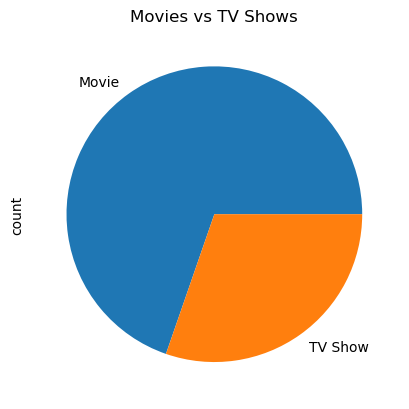

In [32]:
df["type"].value_counts().plot(kind="pie", title="Movies vs TV Shows")

# Movies vs TV Shows Distribution
This chart illustrates the proportion of movies compared to TV shows in the dataset.  
Movies clearly dominate, making up the majority of entries.

<Axes: title={'center': 'Content Added Per Year'}, xlabel='added_year'>

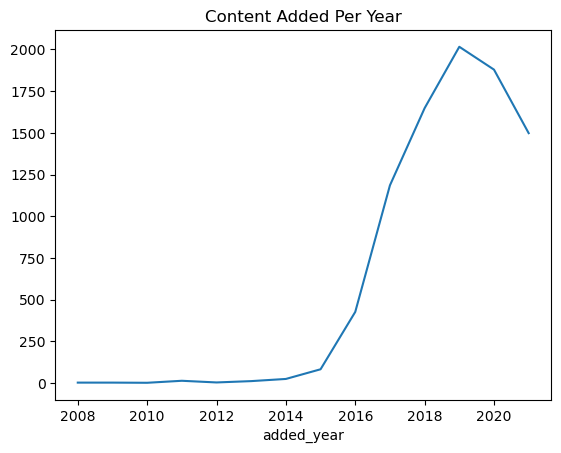

In [34]:
df["added_year"].value_counts().sort_index().plot(
    kind="line",
    title="Content Added Per Year"
)

# Content Added Per Year

This line chart shows how the amount of content added to the platform has changed over time.  
- From **2008 to 2014**, additions were relatively low and stable.  
- Starting around **2015**, there was a sharp increase in new content.  
- The peak occurred between **2019–2020**, reflecting a period of rapid expansion.  
- After 2020, the trend shows a slight decline, suggesting a slowdown in content growth.

*****The dataset highlights Netflix’s aggressive growth strategy in the mid-to-late 2010s, followed*****

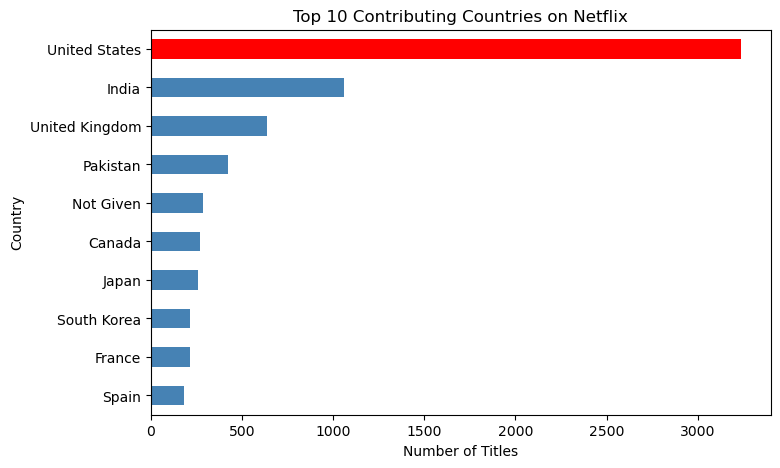

In [47]:
top_countries = df["country"].value_counts().head(10)
top_countries_sorted = top_countries.sort_values()
colors = [
    "red" if country == "United States" else "steelblue"
    for country in top_countries_sorted.index
]
plt.figure(figsize=(8,5))
top_countries_sorted.plot(
    kind="barh",
    color=colors
)
plt.title("Top 10 Contributing Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


# Top 10 Producing Countries

This horizontal bar chart shows the countries contributing the most content.  
- The **United States** stands out as the leading producer, far ahead of others.  
- India and the United Kingdom follow, showing strong contributions.  
- Other countries like Spain, France, and South Korea appear with smaller shares.  

****The dominance of <span style="color:red">United States</span> highlights its central role in Netflix’s catalog, while India and the UK also play significant parts in global content production.***


In [39]:
df_genres = df.explode("listed_in")

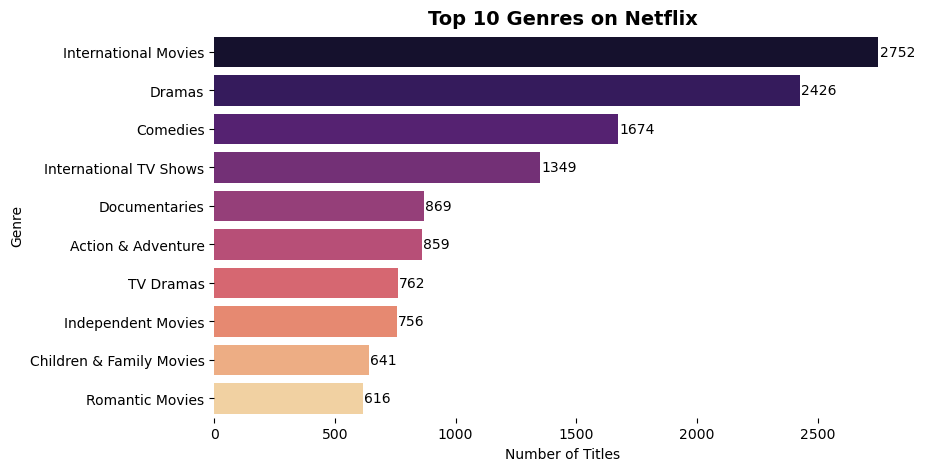

In [52]:
genres = df.explode('listed_in')
top_genres = genres['listed_in'].value_counts().head(10)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,   # ربط الألوان بالـ y
    palette='magma',
    legend=False
)

# إضافة الأرقام على الأعمدة
for i, v in enumerate(top_genres.values):
    ax.text(v + 5, i, str(v), va='center')

plt.title('Top 10 Genres on Netflix', fontsize=14, weight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

sns.despine(left=True, bottom=True)
plt.show()


# Top 10 Genres on Netflix

This chart highlights the most common genres available on Netflix.  
- **Dramas** and **International Movies** dominate the catalog, reflecting Netflix’s global reach and focus on storytelling.  
- **Documentaries** also appear prominently, showing strong demand for factual and educational content.  
- **Comedies** and **Children & Family Movies** are well represented, catering to diverse audiences.  
- Niche categories like **Stand-Up Comedy** and **Independent Movies** contribute to variety but remain smaller in scale.

***Netflix’s library is heavily weighted toward dramas and international films, while still offering a balanced mix of family entertainment, comedies, and documentaries.***
